# Data ETL

In [ ]:
# ETL script to extract DataLogger messages from ROS2 bag files and save them as CSV.

import pathlib
import pandas as pd
from rclpy.serialization import deserialize_message
from rosbag2_py import SequentialReader, StorageOptions, ConverterOptions
from xplorer_mini_common_interfaces.msg import DataLogger
from rosidl_runtime_py.convert import message_to_ordereddict

def main():
    folder = pathlib.Path("./raw")
    bag_paths = [str(i) for i in folder.rglob('*.db3')]
    target_topic = '/xplorer_mini/gnc/record/data_logger'
    
    total_files = len(bag_paths)
    print(f"Found {total_files} bag files. Starting process...\n")

    for bag_file in bag_paths:
        bag_name = pathlib.Path(bag_file).name
        csv_path = pathlib.Path(bag_file).with_suffix('.csv')
        
        data_buffer = [] 

        try:
            storage_options = StorageOptions(uri=bag_file, storage_id='sqlite3')
            converter_options = ConverterOptions('', '')
            reader = SequentialReader()
            reader.open(storage_options, converter_options)
        except Exception as e:
            print(f"[FAIL] {bag_name}: {e}")
            continue

        while reader.has_next():
            (topic, data, t) = reader.read_next()
            
            if topic == target_topic:
                try:
                    msg = deserialize_message(data, DataLogger)
                    msg_dict = message_to_ordereddict(msg)
                    msg_dict['timestamp'] = t
                    data_buffer.append(msg_dict)
                    
                except Exception as e:
                    print(f"[WARN] {bag_name}: Schema Mismatch. Stopping read. ({e})")
                    break 

        # Write to CSV
        if data_buffer:
            try:
                df = pd.json_normalize(data_buffer)
                df.to_csv(csv_path, index=False)
                print(f"[ OK ] {bag_name}: Saved {len(df)} rows")
            except Exception as e:
                print(f"[ERR ] {bag_name}: CSV Write Error {e}")
        else:
            if csv_path.exists(): csv_path.unlink()
            print(f"[SKIP] {bag_name}: No valid data extracted")

if __name__ == '__main__':
    main()

In [5]:
# remove junk files created by Windows OS
import os
import glob

junk_files = glob.glob('**/*:Zone.Identifier', recursive=True)

if junk_files:
    print(f"🧹 Cleaning up {len(junk_files)} junk files...")
    for f in junk_files:
        try:
            os.remove(f)
        except OSError as e:
            print(f"Error deleting {f}: {e}")
else:
    print("✅ No junk files found.")

✅ No junk files found.


# Data Preprocessing

## download raw data

In [6]:
# create minio client 
from minio import Minio
import pandas as pd
import urllib3

# Disable InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Create a custom HTTP client that ignores SSL certificate verification
http_client = urllib3.PoolManager(
    cert_reqs='CERT_NONE',
    assert_hostname=False
)

# Initialize MinIO Client
client = Minio(
    "s3.amarr.tan",         
    access_key='minio_user',
    secret_key='minio_password',
    secure=True,         
    http_client=http_client
)
bucket_name = 'xplorer-mini-data'


In [2]:
# pull raw data from minio server and load into pandas dataframe
prefix = 'raw/'

# List objects in bucket respect to given prefix
objects = client.list_objects(bucket_name, prefix=prefix, recursive=True)
exp = []

for obj in objects:
    key = obj.object_name
    
    if key.endswith('.csv'):
        print(f"📥 Streaming: {key} ...")
        
        try:
            response = client.get_object(bucket_name, key)        
            df = pd.read_csv(response)
            exp.append((key, df))
            
        finally:
            response.close()
            response.release_conn()

📥 Streaming: raw/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113557/xplorer_mini_data_20260126_113557_0.csv ...
📥 Streaming: raw/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113919/xplorer_mini_data_20260126_113919_0.csv ...
📥 Streaming: raw/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123008/xplorer_mini_data_20260126_123008_0.csv ...
📥 Streaming: raw/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123307/xplorer_mini_data_20260126_123307_0.csv ...
📥 Streaming: raw/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_143652/xplorer_mini_data_20260126_143652_0.csv ...
📥 Streaming: raw/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_144153/xplorer_mini_data_20260126_144153_0.csv ...
📥 Streaming: raw/cl_inject/pid/zigzag/rgs/6m/xplorer_mini_data_20260126_121853/xplorer_mini_data_20260126_121853_0.csv ...
📥 Streaming: raw/cl_inject/pid/zigzag/rgs/6m/xplorer_mini_data_20260126_122348/xplorer_mini_data_20260126_122348_0.csv ...
📥 Streamin

In [3]:
# save to minio
import io

def upload_to_minio(bucket_name, data_frames, prefix, suffix):
    for key, df in data_frames:

        key_list = key.split('/')
        key_list.pop(0)  
        key_list.pop(-1) 
        target_key = prefix + '/' + '/'.join(key_list) + '/' + suffix

        csv_data = df.to_csv(index=False).encode('utf-8')
        csv_buffer = io.BytesIO(csv_data)
        
        client.put_object(
            bucket_name,
            target_key,
            data=csv_buffer,
            length=len(csv_data),
            content_type='application/csv'
        )
        print(f"📤 Uploaded to MinIO: {target_key}")

In [4]:
# Extract relevant columns and reshape thruster data

import numpy as np

thurster_col = exp[0][1].columns[['est_joint_state_thruster.effort' in col for col in exp[0][1].columns]]
n_joint = np.array(exp[0][1].loc[0, thurster_col].values[0][1:-1].split(', '), dtype=np.float32)
print(f"Detected {len(n_joint)} thruster joints.")

raw_data_frames = []

for key, df in exp:
    df_time = time = ((exp[0][1].filter(regex='time') - exp[0][1].filter(regex='time').min()).squeeze() / 1e9 ).round(2)
    df_ref_filtered = df.filter(regex='(.*ref.*position)|(.*ref.*orientation)')
    df_est_tau = df.filter(regex='est_tau')
    df_pose = df.filter(regex='(.*odom.*position)|(.*odom.*orientation)')
    df_vel = df.filter(regex='(.*odom.*twist.*linear.*)|(.*odom.*twist.*angular.*)')

    # thruster and rpm 
    thurster_vals = df.filter(regex='est_joint_state_thruster.effort').squeeze().astype(str).str[1:-1].str.split(', ', expand=True).astype(float)
    rpm_vals = df.filter(regex='est_joint_state_thruster.velocity').squeeze().astype(str).str[1:-1].str.split(', ', expand=True).astype(float)
    df_thurster = pd.DataFrame(columns=[f'thruster_{i}' for i in range(len(n_joint))], data=thurster_vals.values)
    df_rpm = pd.DataFrame(columns=[f'rpm_{i}' for i in range(len(n_joint))], data=rpm_vals.values)
    
    # Concatenate all relevant data into a single DataFrame for each file
    raw_data_frames.append((key, pd.concat([df_time, df_ref_filtered, df_est_tau, df_pose, df_vel, df_thurster, df_rpm], axis=1)))

Detected 8 thruster joints.


## Clean raw data

In [11]:
# Outlier Removal using Hampel Filter (Vectorized)
from scipy import signal
import numpy as np
import pandas as pd
from scipy.ndimage import median_filter

def hampel_filter_vectorized(df, window_size=5, n_sigmas=3):
    """
    Apply Hampel Filter on the entire DataFrame at once (Vectorized).
    """
    k = 1.4826
    kernel_size = (2 * window_size + 1, 1) 
    arr = df.values.astype(float)
    rolling_median = median_filter(arr, size=kernel_size, mode='nearest')
    difference = np.abs(arr - rolling_median)
    mad = median_filter(difference, size=kernel_size, mode='nearest')
    threshold = n_sigmas * k * mad
    outlier_mask = difference > threshold
    cleaned_arr = arr.copy()
    cleaned_arr[outlier_mask] = rolling_median[outlier_mask]
    return pd.DataFrame(cleaned_arr, index=df.index, columns=df.columns)

def check_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).any()

cleaned_data_frames = []

# parameters for Hampel Filter
window_size = 20
n_sigmas = 20

# apply Hampel Filter to each column with outliers detected by IQR method
for key, df in raw_data_frames: 
    print(f"📦 Processing: {key}")
    df_clean = df.copy()
    cols_to_process = df.columns.difference(['timestamp'])

    for col in cols_to_process:
        if check_outliers_iqr(df[col]):
            print(f"  ⚠️ Outlier detected in '{col}' -> Applying Hampel Filter")
            df_col_cleaned = hampel_filter_vectorized(df[[col]], window_size=window_size, n_sigmas=n_sigmas)
            df_clean[col] = df_col_cleaned[col].values
        else:
            pass
    cleaned_data_frames.append((key, df_clean))

print("\n✅ All sequences processed successfully.")

NameError: name 'raw_data_frames' is not defined

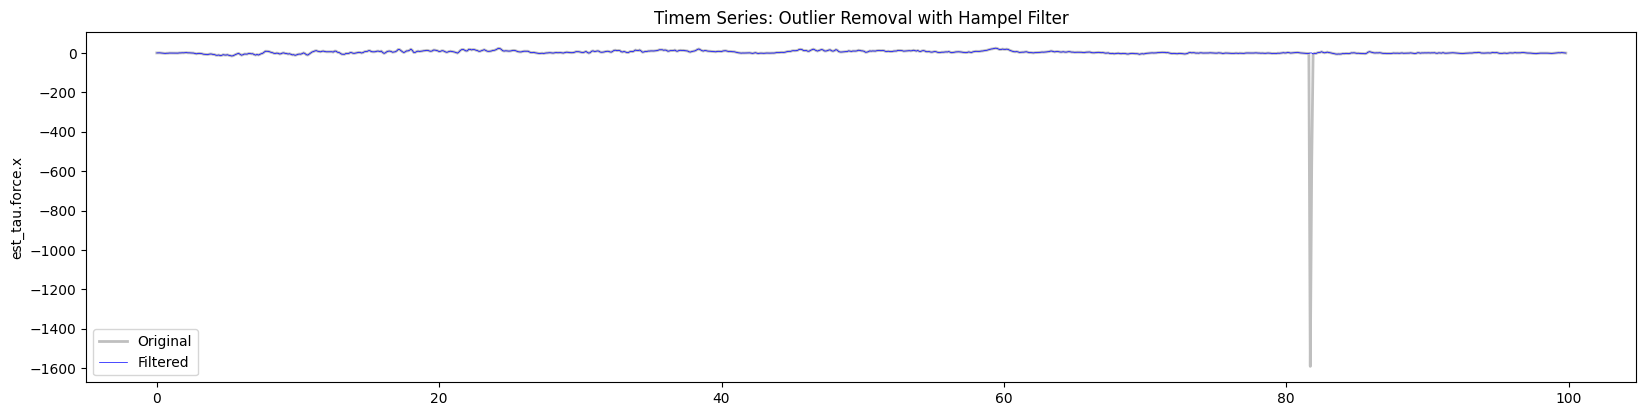

In [13]:
# visualize the effect of filtering on one sequence
import matplotlib.pyplot as plt
selected_exp_idx = 7

key, df_raw = raw_data_frames[selected_exp_idx]
_, df_filt = cleaned_data_frames[selected_exp_idx]
name_filter = 'tau.*f.*x'
# name_filter = 'odom.*position.*z'
# name_filter = 'odom.*twist.*linear.*z'
# name_filter = 'odom.*twist.*angular.*y'
plt.figure(figsize=(20, 10))
ax = plt.subplot(2, 1, 1)
ax.plot(df_raw['timestamp'], df_raw.filter(regex=name_filter), label='Original', color='gray', alpha=0.5, linewidth=2)
ax.plot(df_filt['timestamp'], df_filt.filter(regex=name_filter), label='Filtered', color='blue', linewidth=0.5)
ax.set_title("Timem Series: Outlier Removal with Hampel Filter")
ax.set_ylabel(df_raw.filter(regex=name_filter).columns[0])
ax.legend()

In [ ]:
# Upload cleaned data to MinIO
suffix = f'hampel_window{window_size}_sigma{n_sigmas}.csv'
upload_to_minio("xplorer-mini-data", cleaned_data_frames, 'cleaned', suffix=suffix)

📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113557/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113919/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123008/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123307/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_143652/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_144153/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/6m/xplorer_mini_data_20260126_121853/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid/zigzag/rgs/6m/xplorer_mini_data_20260126_122348/hampel_window30_sigma20.csv
📤 Uploaded to MinIO: cleaned/cl_inject/pid

## Smooth cleaned data

In [7]:
# Pull cleaned data with specific suffix
# parameters for filtering cleaned files
window_size = 20
n_sigmas = 20
filter_suffix = f'hampel_window{window_size}_sigma{n_sigmas}.csv'

objects = client.list_objects(bucket_name, prefix='cleaned/', recursive=True)
clean_exp = []

for obj in objects:
    key = obj.object_name
    if key.endswith(filter_suffix):
        print(f"📥 Streaming: {key} ...")
        try:
            response = client.get_object(bucket_name, key)        
            df = pd.read_csv(response)
            clean_exp.append((key, df))
        finally:
            response.close()
            response.release_conn()

📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113557/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113919/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123008/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123307/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_143652/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_144153/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/6m/xplorer_mini_data_20260126_121853/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/6m/xplorer_mini_data_20260126_122348/hampel_window20_sigma20.csv ...
📥 Streaming: cleaned/cl_inject/pid/zigzag/rgs/6m/xplorer_mini_data_2026012

In [12]:
# apply Butterworth low-pass filter for smoothing
import scipy.signal as signal

def moving_average_filter(df, window_size):
    return df.rolling(window=window_size, center=True, min_periods=1).mean()

def butterworth_lowpass_filter(df, cutoff_freq, fs, order):
    sos = signal.butter(order, cutoff_freq, 'low', fs=fs, output='sos')
    return df.apply(lambda x: signal.sosfiltfilt(sos, x))

def apply_filter(clean_exp, method='butter', kwargs={}):
    smooth_df_list = []

    if method == 'ma':
        for key, df in clean_exp:
            print(f"\n🔍 Applying Moving Average Filter (Window Size: {kwargs.get('window_size', 5)}) ...")
            smooth_df_list.append((key, moving_average_filter(df, kwargs.get('window_size', 5))))
    
    if method == 'butter':
        print(f"\n🔍 Applying Butterworth Low-Pass Filter (Order: {kwargs.get('order', 4)}, Cutoff: {kwargs.get('fc', 0.5)}Hz) ...")
        for key, df in clean_exp:
            sos = signal.butter(kwargs.get('order', 4), kwargs.get('fc', 0.5), 'low', fs=fs, output='sos')
            print(f"  🌊 Smoothing {key} with Butterworth LPF (Order {kwargs.get('order', 4)}, {kwargs.get('fc', 0.5)}Hz) ...")
            df_smooth = df.apply(lambda x: signal.sosfiltfilt(sos, x))
            smooth_df_list.append((key, df_smooth))

    return smooth_df_list

clean_method_name = filter_suffix.split('.')[0]

# MA low-pass filter
# window_ma = 5
# smooth_df_list = apply_filter(clean_exp, method='ma', kwargs={'window_size': window_ma})
# suffix_ma = clean_method_name + '/' + f'ma_window{window_ma}.csv'
# upload_to_minio("xplorer-mini-data", smooth_df_list, 'smoothed', suffix=suffix_ma)

# butterworth low-pass filter
fs = 10.0      # Sampling frequency (T=0.1)
fc = 0.5      # Cut-off frequency (Hz)
order = 4      # Order 4 
smooth_df_list = apply_filter(clean_exp, method='butter', kwargs={'order': order, 'fc': fc, 'fs': fs})
smooth_butter_name = clean_method_name + '/' + f'butter_order{order}_fc{fc}Hz.csv'
# upload_to_minio("xplorer-mini-data", smooth_df_list, 'smoothed', suffix=smooth_butter_name)


🔍 Applying Butterworth Low-Pass Filter (Order: 4, Cutoff: 0.5Hz) ...
  🌊 Smoothing cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113557/hampel_window20_sigma20.csv with Butterworth LPF (Order 4, 0.5Hz) ...
  🌊 Smoothing cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113919/hampel_window20_sigma20.csv with Butterworth LPF (Order 4, 0.5Hz) ...
  🌊 Smoothing cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123008/hampel_window20_sigma20.csv with Butterworth LPF (Order 4, 0.5Hz) ...
  🌊 Smoothing cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123307/hampel_window20_sigma20.csv with Butterworth LPF (Order 4, 0.5Hz) ...
  🌊 Smoothing cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_143652/hampel_window20_sigma20.csv with Butterworth LPF (Order 4, 0.5Hz) ...
  🌊 Smoothing cleaned/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_144153/hampel_window20_sigma20.csv with Butterworth LPF (Order 4, 0.5Hz) ...


In [10]:
# plot compare filter and smooth 
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.fft import fft, fftfreq
import pandas as pd

import numpy as np
import pandas as pd
from scipy import signal

def get_fft_db(d, fs_val):
    n_val = len(d)
    win = signal.windows.hann(n_val)
    yf_val = fft(d * win)
    scaling_val = 2.0 / np.sum(win)
    xf_val = fftfreq(n_val, 1/fs_val)[:n_val//2]
    amp_val = scaling_val * np.abs(yf_val[0:n_val//2])
    return xf_val, 20 * np.log10(amp_val + 1e-9)

def calculate_snr_psd(series, fs=10.0):
    """
    Calculate SNR using Power Spectral Density (Welch's method).
    Signal Power = Peak of PSD (Representing the main dynamics)
    Noise Power = Median of PSD (Representing the white noise floor)
    """
    data = series.dropna().values
    if len(data) < 256: 
        nperseg = len(data)
    else:
        nperseg = 256
        
    data_detrended = signal.detrend(data)
    f, Pxx = signal.welch(data_detrended, fs=fs, nperseg=nperseg)
    sig_p = np.max(Pxx)
    noise_p = np.median(Pxx)
    snr_db = 10 * np.log10(sig_p / (noise_p + 1e-12))
    return snr_db

snr_reports = []
FS = 10.0 

for exp_idx, (key, df_smooth) in enumerate(smooth_df_list):
    df_raw = smooth_df_list[exp_idx][1]
    cols = df_smooth.columns.difference(['timestamp'])
    snr_entry = {'Experiment': key}
    for col in cols:
        snr_val = calculate_snr_psd(df_raw[col], fs=FS)
        snr_entry[col] = snr_val
        
    snr_reports.append(snr_entry)

snr_summary_df = pd.DataFrame(snr_reports)
avg_snr_per_state = snr_summary_df.drop(columns=['Experiment']).mean()

print("--- [GLOBAL] Average SNR per State using PSD (All Experiments) ---")
print(avg_snr_per_state.filter(regex='est_tau|odom.*twist.*'))

# plot compare filter and smooth for one state
name_filter = 'tau.*t.*z'
# name_filter = 'odom.*position.*z'
# name_filter = 'odom.*twist.*linear.*x'
# name_filter = 'odom.*twist.*angular.*x'
exp_id = 12

# --- 1. Data Preparation ---
cleaned_data = cleaned_data_frames[exp_id][1].filter(regex=name_filter).values.flatten()
smooth_data = smooth_df_list[exp_id][1].filter(regex=name_filter).values.flatten()
fs = 10.0 
N = len(cleaned_data)

snr_db_raw = calculate_snr_psd(pd.Series(cleaned_data), fs=fs)
snr_db_filt = calculate_snr_psd(pd.Series(smooth_data), fs=fs)  

xf_raw, db_raw = get_fft_db(cleaned_data, fs)
xf_filt, db_filt = get_fft_db(smooth_data, fs)

# # --- 6. Plotting Comparison ---
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

# Top: Time Domain
ax[0].plot(cleaned_data, label=f'Raw Data (SNR: {snr_db_raw:.2f} dB)', color='gray', alpha=0.5)
ax[0].plot(smooth_data, label=f'Filtered Data (SNR: {snr_db_filt:.2f} dB)', color='blue', linewidth=2)
ax[0].set_title("Time Domain: Before vs After Butterworth Filter")
ax[0].set_ylabel("Amplitude")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Bottom: Frequency Domain (FFT)
ax[1].plot(xf_raw, db_raw, label='Original Spectrum', color='gray', alpha=0.5)
ax[1].plot(xf_filt, db_filt, label='Filtered Spectrum', color='red', linewidth=1.5)
ax[1].set_title("Frequency Domain: Noise Floor Reduction")
ax[1].set_ylabel("Amplitude (dB)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].legend()
ax[1].grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

--- [GLOBAL] Average SNR per State using PSD (All Experiments) ---
est_tau.force.x                        43.593506
est_tau.force.y                        51.720838
est_tau.force.z                        40.389263
est_tau.torque.x                       32.630664
est_tau.torque.y                       39.066196
est_tau.torque.z                       36.420072
odom_filtered.twist.twist.angular.x    45.893833
odom_filtered.twist.twist.angular.y    48.986969
odom_filtered.twist.twist.angular.z    52.546288
odom_filtered.twist.twist.linear.x     55.120157
odom_filtered.twist.twist.linear.y     53.325867
odom_filtered.twist.twist.linear.z     40.063477
dtype: float64


NameError: name 'cleaned_data_frames' is not defined

In [ ]:
import re

obj = client.list_objects(bucket_name, prefix='smoothed/', recursive=True)

select_cleaner = r'hampel.*20.*20'
select_smoother = r'butter.*0.5'

smooth_loader = []
for obj in client.list_objects(bucket_name, prefix='smoothed/', recursive=True):
    key = obj.object_name
    if re.search(select_cleaner, key) and re.search(select_smoother, key):
        print(f"📥 Found matching smoothed file: {key}")
        try:
            response = client.get_object(bucket_name, key)        
            df = pd.read_csv(response)
            smooth_loader.append((key, df))
        finally:
            response.close()
            response.release_conn()

📥 Found matching smoothed file: smoothed/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113557/hampel_window20_sigma20/butter_order4_fc0.5Hz.csv
📥 Found matching smoothed file: smoothed/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_113919/hampel_window20_sigma20/butter_order4_fc0.5Hz.csv
📥 Found matching smoothed file: smoothed/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123008/hampel_window20_sigma20/butter_order4_fc0.5Hz.csv
📥 Found matching smoothed file: smoothed/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_123307/hampel_window20_sigma20/butter_order4_fc0.5Hz.csv
📥 Found matching smoothed file: smoothed/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_143652/hampel_window20_sigma20/butter_order4_fc0.5Hz.csv
📥 Found matching smoothed file: smoothed/cl_inject/pid/zigzag/rgs/10m/xplorer_mini_data_20260126_144153/hampel_window20_sigma20/butter_order4_fc0.5Hz.csv
📥 Found matching smoothed file: smoothed/cl_inject/pid/zigzag/rgs/6m/xplorer

In [2]:
import mlflow
from mlflow.tracking import MlflowClient

def hard_delete_mlflow_model(model_name):
    client = MlflowClient(tracking_uri="https://mlflow.amarr.tan")  # Specify your MLflow tracking URI
    
    try:
        model_versions = client.get_registered_model(model_name).latest_versions
        print(f"Found {len(model_versions)} versions for model: '{model_name}'")
        
        for version in model_versions:
            print(f"Deleting version {version.version}...")
            client.transition_model_version_stage(
                name=model_name,
                version=version.version,
                stage="Archived"
            )
            client.delete_model_version(name=model_name, version=version.version)

        client.delete_registered_model(name=model_name)
        print(f"Successfully hard deleted registered model: '{model_name}'")
        
    except mlflow.exceptions.RestException as e:
        print(f"Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# --- ใช้งาน ---
hard_delete_mlflow_model("dmdc")

Error: RESOURCE_DOES_NOT_EXIST: Registered Model with name=dmdc not found


/home/tanbjs/xplorer_mini_sysid/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow.amarr.tan'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [13]:
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

run_id = "0f82065bd1e74397abbe2aabc29ae56e"

tags_to_clear = [
    "mlflow.log-model.history",
    "mlflow.registered_model_name",
    "mlflow.registered_model_version"
]

for tag in tags_to_clear:
    try:
        client.set_tag(run_id, tag, "")
        print(f"Cleared tag: {tag}")
    except Exception as e:
        print(f"Could not clear tag {tag}: {e}")

print("\n--- Process Finished ---")
print("กรุณาทำ Hard Refresh (Ctrl + F5) ที่หน้าเบราว์เซอร์อีกครั้ง")

Cleared tag: mlflow.log-model.history
Cleared tag: mlflow.registered_model_name
Cleared tag: mlflow.registered_model_version

--- Process Finished ---
กรุณาทำ Hard Refresh (Ctrl + F5) ที่หน้าเบราว์เซอร์อีกครั้ง
